# Investigando o Catálogo da Netflix

**Disciplina:** LIA1  
**Aluno:** Rui Gonçalves de Oliveira Júnior  
**Matrícula:** 201910831  

---

## A Missão (Objetivos)
Nesta análise, vamos explorar o dataset **Netflix Movies and TV Shows**. https://www.kaggle.com/datasets/shivamb/netflix-shows

O objetivo é desvendar as estratégias da gigante do streaming e entender como o catálogo está estruturado.

- Comparar a quantidade de Filmes versus Séries.
- Descobrir quais países produzem mais conteúdo para a plataforma.
- Rastrear a evolução dos lançamentos ao longo dos anos.
- Investigar a duração dos filmes e identificar outliers (filmes curtos demais ou longos demais).
- Identificar as limitações do dataset na busca pelos "melhores" títulos e buscar destaques alternativos.


---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracao de tema e estilo
sns.set_theme(style="darkgrid")
sns.set_palette("magma")

# Evitar alertas desnecessarios
import warnings
warnings.filterwarnings('ignore')

print("Configuracoes ok")

Configuracoes ok


## Checkpoint 1: Carregando o Catalogo
Importando a base de dados e visualizando os primeiros registros.

In [2]:
df = pd.read_csv('netflix_titles.csv')
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Missao 1: Filmes ou Series?
O que domina o catalogo da Netflix? Vamos usar um **Grafico de Barras** para comparar o volume total de filmes e de series de TV.

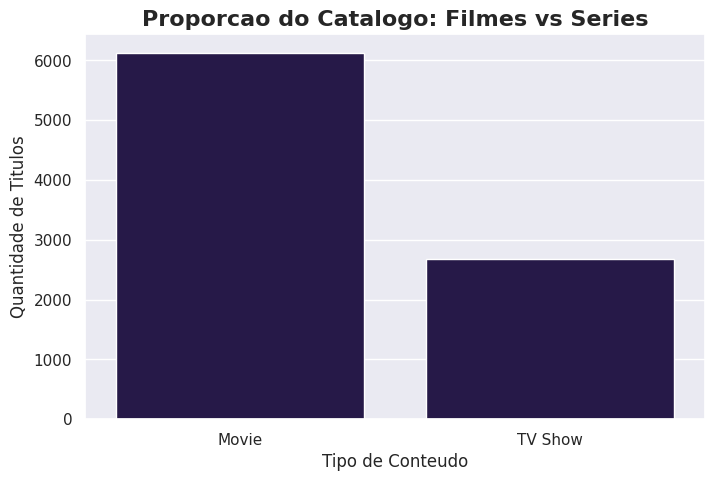

In [3]:
plt.figure(figsize=(8, 5))

sns.countplot(x='type', data=df)

plt.title('Proporcao do Catalogo: Filmes vs Series', fontsize=16, fontweight='bold')
plt.xlabel('Tipo de Conteudo', fontsize=12)
plt.ylabel('Quantidade de Titulos', fontsize=12)
plt.show()

## Missao 2: Potencias do Entretenimento
Quais paises tem mais titulos originais ou licenciados disponiveis? Vamos listar o Top 20 produtores de conteudo.

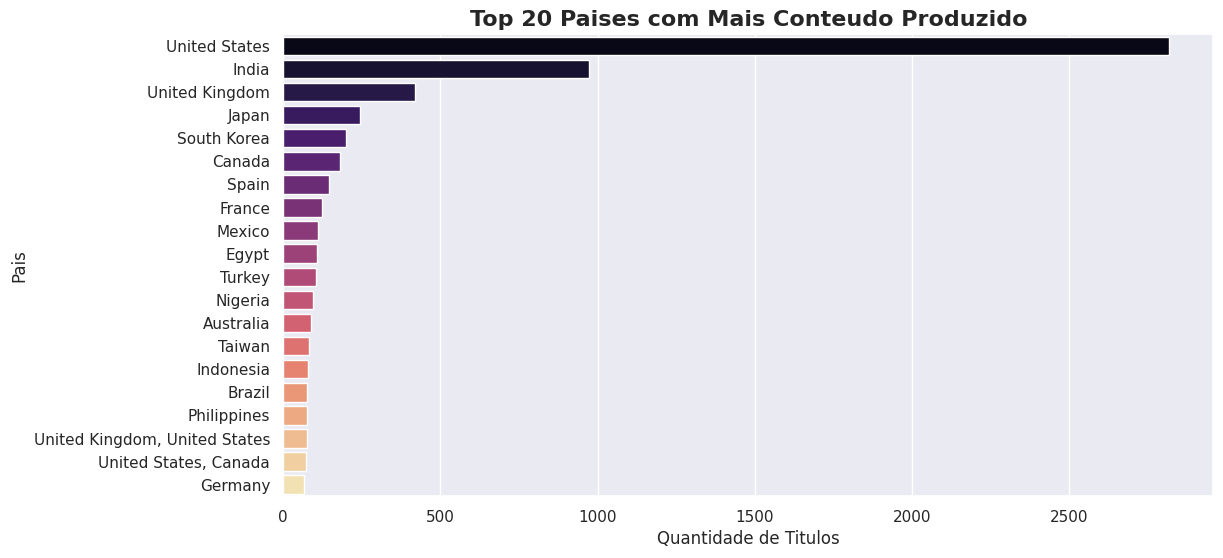

In [4]:
plt.figure(figsize=(12, 6))

# Contando valores e pegando os 10 primeiros paises
top_paises = df['country'].value_counts().head(20)

sns.barplot(y=top_paises.index, x=top_paises.values, palette="magma")

plt.title('Top 20 Paises com Mais Conteudo Produzido', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Titulos', fontsize=12)
plt.ylabel('Pais', fontsize=12)
plt.show()

## Missao 3: A Explosao do Streaming
Como foi o ritmo de lancamento de conteudos ao longo dos anos? Usaremos um **Grafico de Linha** focado nos conteudos lancados do ano 2000 em diante.

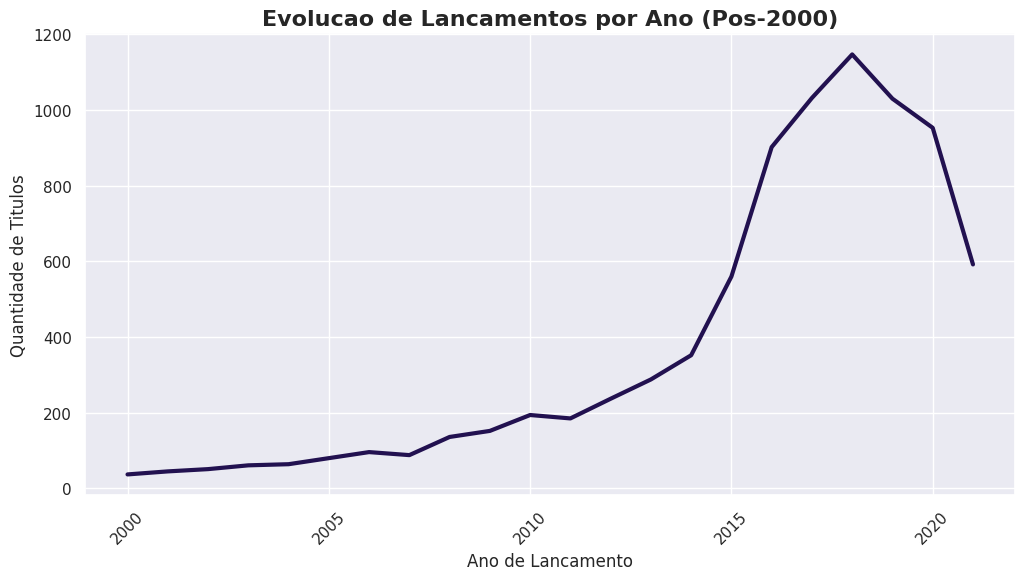

In [5]:
plt.figure(figsize=(12, 6))

# Filtrando titulos lancados do ano 2000 em diante para focar na era moderna
df_recentes = df[df['release_year'] >= 2000]
lancamentos_por_ano = df_recentes['release_year'].value_counts().sort_index()

sns.lineplot(x=lancamentos_por_ano.index, y=lancamentos_por_ano.values, linewidth=3)

plt.title('Evolucao de Lancamentos por Ano (Pos-2000)', fontsize=16, fontweight='bold')
plt.xlabel('Ano de Lancamento', fontsize=12)
plt.ylabel('Quantidade de Titulos', fontsize=12)
plt.xticks(rotation=45)
plt.show()

## Missao 4: Quantidade vs Duracao (Boxplot)
Qual e a duracao media de um filme na Netflix? Precisamos limpar a coluna de duracao, extrair os numeros e usar um **Boxplot** para ver a distribuicao e encontrar os filmes muito curtos ou extremamente longos.

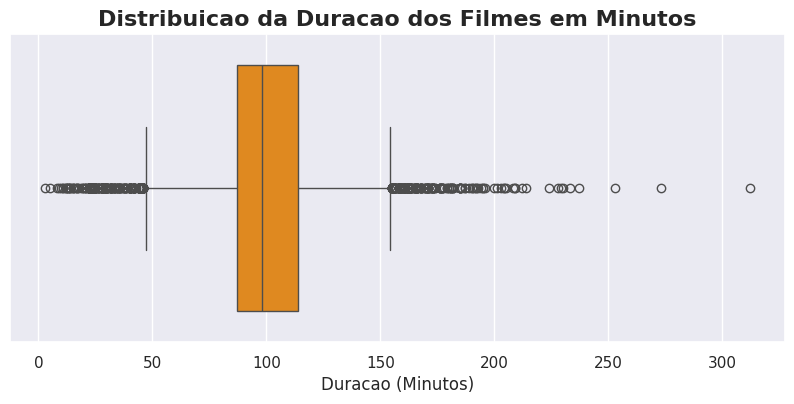

In [6]:
plt.figure(figsize=(10, 4))

# Filtrando apenas filmes
filmes = df[df['type'] == 'Movie'].copy()

# Limpando o texto ' min' da coluna duration e convertendo para numero (float/int)
filmes['duration_min'] = filmes['duration'].fillna('0 min').apply(lambda x: int(str(x).split(' ')[0]))
filmes = filmes[filmes['duration_min'] > 0] # Removendo dados vazios acidentais

sns.boxplot(x=filmes['duration_min'], color='darkorange')

plt.title('Distribuicao da Duracao dos Filmes em Minutos', fontsize=16, fontweight='bold')
plt.xlabel('Duracao (Minutos)', fontsize=12)
plt.show()

## Missao 5: Quantidade vs Duracao
Para fechar nossa analise de duracao, vamos criar um grafico simples mostrando a quantidade exata de filmes para cada faixa de duracao usando um **Histograma**.

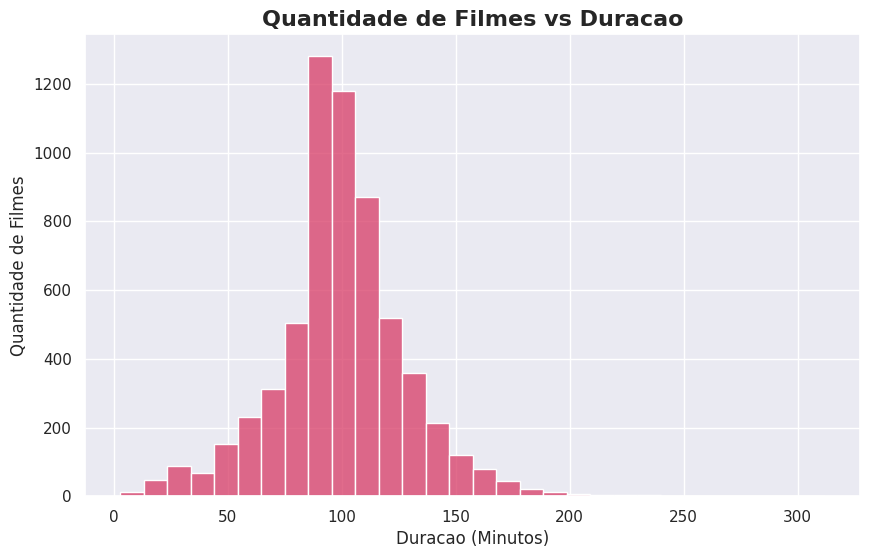

In [7]:
plt.figure(figsize=(10, 6))

# Histograma simples para visualizar a quantidade de filmes por tempo
sns.histplot(data=filmes, x='duration_min', bins=30, color='#d83b66')

plt.title('Quantidade de Filmes vs Duracao', fontsize=16, fontweight='bold')
plt.xlabel('Duracao (Minutos)', fontsize=12)
plt.ylabel('Quantidade de Filmes', fontsize=12)
plt.show()

## Missao 6: Os Extremos do Tempo (Analisando Outliers)
Vamos investigar a fundo aqueles pontos que fugiram do padrao no nosso Boxplot (Missao 4). Quais sao os filmes mais curtos e os mais longos disponiveis no catalogo?

In [10]:
print("\n--- TOP 10 FILMES MAIS CURTOS (MAIS RAPIDOS) ---")
filmes_curtos = filmes[['title', 'duration_min', 'listed_in']].sort_values('duration_min').head(10)
display(filmes_curtos)

print("\n--- TOP 10 FILMES MAIS LONGOS ---")
filmes_longos = filmes[['title', 'duration_min', 'listed_in']].sort_values('duration_min', ascending=False).head(10)
display(filmes_longos)


--- TOP 10 FILMES MAIS CURTOS (MAIS RAPIDOS) ---


,title,duration_min,listed_in
3777,Silent,3,"Children & Family Movies, Sci-Fi & Fantasy"
2713,Sol Levante,5,"Action & Adventure, Anime Features, Internatio..."
1484,Cops and Robbers,8,Dramas
1557,Canvas,9,"Children & Family Movies, Dramas"
3535,American Factory: A Conversation with the Obamas,10,Documentaries
6405,Calico Critters: A Town of Dreams,11,Children & Family Movies
2858,Calico Critters: Everyone's Big Dream Flying i...,11,Children & Family Movies
695,Besieged Bread,12,"Dramas, International Movies"
3775,Cosmos Laundromat: First Cycle,12,"Dramas, International Movies, Sci-Fi & Fantasy"
4707,Zion,12,"Documentaries, Sports Movies"



--- TOP 10 FILMES MAIS LONGOS ---


,title,duration_min,listed_in
4253,Black Mirror: Bandersnatch,312,"Dramas, International Movies, Sci-Fi & Fantasy"
717,Headspace: Unwind Your Mind,273,Documentaries
2491,The School of Mischief,253,"Comedies, Dramas, International Movies"
2487,No Longer kids,237,"Comedies, Dramas, International Movies"
2484,Lock Your Girls In,233,"Comedies, International Movies, Romantic Movies"
2488,Raya and Sakina,230,"Comedies, Dramas, International Movies"
166,Once Upon a Time in America,229,"Classic Movies, Dramas"
7932,Sangam,228,"Classic Movies, Dramas, International Movies"
1019,Lagaan,224,"Dramas, International Movies, Music & Musicals"
4573,Jodhaa Akbar,214,"Action & Adventure, Dramas, International Movies"


## Missao 7: Em Busca dos Melhores Titulos
Tentei buscar os 'melhores' filmes e series. Mas encontrei um obstaculo: **este dataset nao possui uma coluna de notas de usuarios (como IMDb ou Rotten Tomatoes)**.

Para compensar,vamos buscar os 10 mais recentes e antigos de filmes e series.

In [13]:
print("\n--- TOP 10 FILMES MAIS ANTIGOS ---")
top_filmes_recentes = df[df['type'] == 'Movie'].sort_values('release_year', ascending=True)[['title', 'release_year', 'country']].head(10)
display(top_filmes_recentes)

print("\n--- TOP 10 SERIES MAIS ANTIGOS ---")
top_series_recentes = df[df['type'] == 'TV Show'].sort_values('release_year', ascending=True)[['title', 'release_year', 'country']].head(10)
display(top_series_recentes)

print("\n--- TOP 10 FILMES MAIS RECENTES ---")
top_filmes_recentes = df[df['type'] == 'Movie'].sort_values('release_year', ascending=False)[['title', 'release_year', 'country']].head(10)
display(top_filmes_recentes)

print("\n--- TOP 10 SERIES MAIS RECENTES ---")
top_series_recentes = df[df['type'] == 'TV Show'].sort_values('release_year', ascending=False)[['title', 'release_year', 'country']].head(10)
display(top_series_recentes)


--- TOP 10 FILMES MAIS ANTIGOS ---


,title,release_year,country
7790,Prelude to War,1942,United States
8205,The Battle of Midway,1942,United States
8660,Undercover: How to Operate Behind Enemy Lines,1943,United States
8739,Why We Fight: The Battle of Russia,1943,United States
8763,WWII: Report from the Aleutians,1943,United States
8419,The Memphis Belle: A Story of a\nFlying Fortress,1944,United States
8436,The Negro Soldier,1944,United States
8640,Tunisian Victory,1944,"United States, United Kingdom"
7575,Nazi Concentration Camps,1945,United States
7219,Know Your Enemy - Japan,1945,United States



--- TOP 10 SERIES MAIS ANTIGOS ---


,title,release_year,country
4250,Pioneers: First Women Filmmakers*,1925,NaN
1331,Five Came Back: The Reference Films,1945,United States
7743,Pioneers of African-American Cinema,1946,United States
8541,The Twilight Zone (Original Series),1963,United States
8189,The Andy Griffith Show,1967,United States
4550,Monty Python's Fliegender Zirkus,1972,"United Kingdom, West Germany"
4551,Monty Python's Flying Circus,1974,United Kingdom
6549,Dad's Army,1977,United Kingdom
6674,El Chavo,1979,Mexico
7588,Ninja Hattori,1981,Japan



--- TOP 10 FILMES MAIS RECENTES ---


,title,release_year,country
45,My Heroes Were Cowboys,2021,NaN
36,The Stronghold,2021,NaN
35,The Father Who Moves Mountains,2021,NaN
30,Ankahi Kahaniya,2021,NaN
64,Nightbooks,2021,NaN
68,Schumacher,2021,NaN
71,A StoryBots Space Adventure,2021,NaN
1218,YES DAY,2021,United States
1212,Paper Lives,2021,Turkey
1202,C/O Kaadhal,2021,India



--- TOP 10 SERIES MAIS RECENTES ---


,title,release_year,country
83,Metal Shop Masters,2021,NaN
5,Midnight Mass,2021,NaN
8,The Great British Baking Show,2021,United Kingdom
1,Blood & Water,2021,South Africa
2,Ganglands,2021,NaN
4,Kota Factory,2021,India
95,The Circle,2021,"United States, United Kingdom"
97,Kid Cosmic,2021,United States
98,Octonauts: Above & Beyond,2021,United Kingdom
99,On the Verge,2021,"France, United States"


---
# Conclusao: 

### Insights Estrategicos:
- **Filmes x Series:** O catalogo e predominantemente focado em filmes, possuindo um volume consideravelmente maior de longas-metragens em comparacao as series.
- **Geografia:** Os Estados Unidos dominam absolutamente a producao de conteudo da plataforma, seguidos pela India (impulsionada fortemente pelas producoes de Bollywood).
- **Evolucao Temporal:** O grafico de linha revela uma explosao de titulos a partir de 2015, marcando a ascensao do streaming e o inicio pesado das producoes originais Netflix.
- **Duracao dos Filmes:** O Boxplot mostra que o "padrao da industria" se mantem: a maioria dos filmes dura entre 90 e 110 minutos.
- **Os Extremos (Outliers):** Ao listar os extremos de tempo, descobrimos que os filmes muito curtos (outliers inferiores) geralmente sao animacoes ou documentarios curtos. Já os mais longos (outliers superiores) costumam ser grandes epicos ou producoes indianas que passam facilmente da marca de 3 horas.
- **A Pegadinha dos Dados:** Percebemos criticamente que a base carece de avaliacoes (scores) para definir os "melhores" titulos. Em um cenario corporativo real, precisariamos cruzar esta base de dados com uma API do IMDb para obter essa resposta com precisao estatistica!
